In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn
%matplotlib inline

from sklearn.datasets import load_digits
digits = load_digits()

In [2]:
df = pd.DataFrame(digits.data, columns=digits.feature_names)
df['target'] = digits.target
df.head()

,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,...,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7,target
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4


In [4]:

print("Feature shape :", digits.data.shape)
print("Target classes:", digits.target_names)
print("Total samples :", len(digits.data))

Feature shape : (1797, 64)
Target classes: [0 1 2 3 4 5 6 7 8 9]
Total samples : 1797


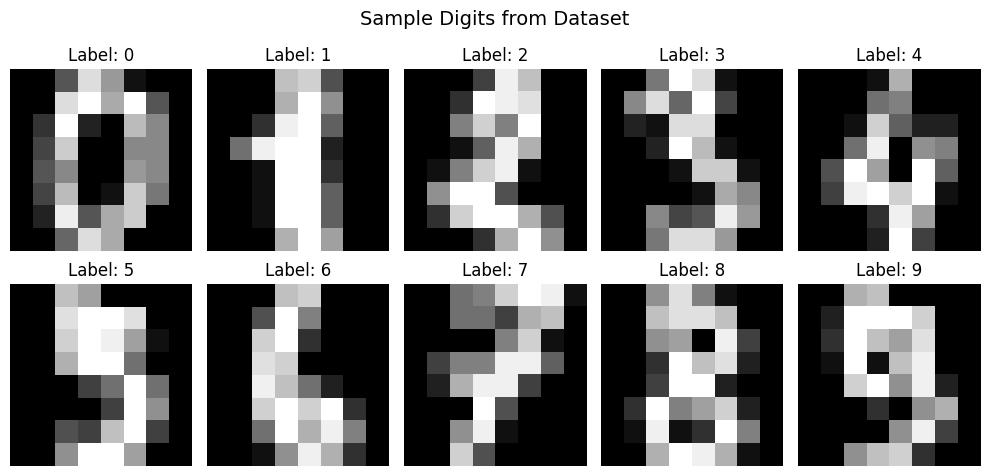

In [5]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap='gray')
    ax.set_title(f"Label: {digits.target[i]}")
    ax.axis('off')
plt.suptitle("Sample Digits from Dataset", fontsize=14)
plt.tight_layout()
plt.show()

TRAIN-TEST SPLIT

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    digits.data, digits.target,
    test_size=0.2,
    random_state=42
)

print("Train size:", X_train.shape)
print("Test size :", X_test.shape)

Train size: (1437, 64)
Test size : (360, 64)


In [7]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {'n_neighbors': list(range(1, 21))}   # K from 1 to 20

grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5,
    scoring='accuracy'
)
grid.fit(X_train, y_train)

best_k     = grid.best_params_['n_neighbors']
best_score = grid.best_score_

print(f"Best K     : {best_k}")
print(f"Best CV Score (train): {best_score:.4f}")

Best K     : 1
Best CV Score (train): 0.9861


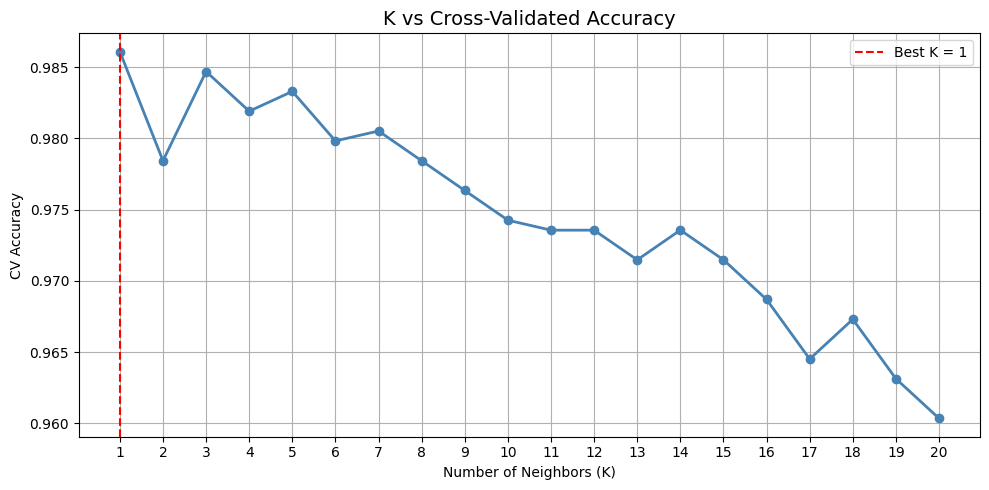

In [10]:
k_values   = list(range(1, 21))
cv_scores  = grid.cv_results_['mean_test_score']

plt.figure(figsize=(10, 5))
plt.plot(k_values, cv_scores, marker='o', color='steelblue', linewidth=2)
plt.axvline(x=best_k, color='red', linestyle='--', label=f'Best K = {best_k}')
plt.title('K vs Cross-Validated Accuracy', fontsize=14)
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('CV Accuracy')
plt.xticks(k_values)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [11]:
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train, y_train)

test_score = knn.score(X_test, y_test)
print(f"Test Accuracy with K={best_k}: {test_score:.4f}")

Test Accuracy with K=1: 0.9778


In [12]:
from sklearn.metrics import confusion_matrix

y_pred = knn.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[33  0  0  0  0  0  0  0  0  0]
 [ 0 28  0  0  0  0  0  0  0  0]
 [ 0  0 33  0  0  0  0  0  0  0]
 [ 0  0  0 34  0  0  0  0  0  0]
 [ 0  1  0  0 45  0  0  0  0  0]
 [ 0  0  0  0  0 46  1  0  0  0]
 [ 0  0  0  0  0  0 35  0  0  0]
 [ 0  0  0  0  0  0  0 33  0  1]
 [ 0  1  0  0  0  0  0  0 28  1]
 [ 0  0  0  1  1  1  0  0  0 37]]


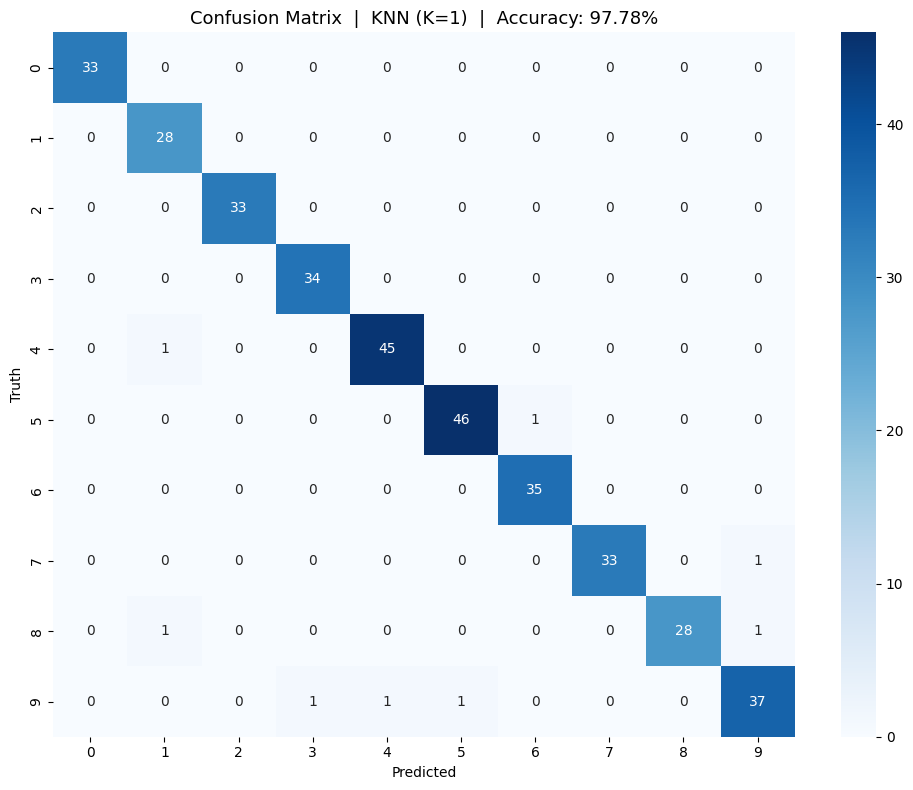

In [13]:
plt.figure(figsize=(10, 8))
sn.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=digits.target_names,
    yticklabels=digits.target_names
)
plt.title(f'Confusion Matrix  |  KNN (K={best_k})  |  Accuracy: {test_score*100:.2f}%', fontsize=13)
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.tight_layout()
plt.show()

In [14]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, target_names=[str(i) for i in digits.target_names]))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       0.93      1.00      0.97        28
           2       1.00      1.00      1.00        33
           3       0.97      1.00      0.99        34
           4       0.98      0.98      0.98        46
           5       0.98      0.98      0.98        47
           6       0.97      1.00      0.99        35
           7       1.00      0.97      0.99        34
           8       1.00      0.93      0.97        30
           9       0.95      0.93      0.94        40

    accuracy                           0.98       360
   macro avg       0.98      0.98      0.98       360
weighted avg       0.98      0.98      0.98       360



In [15]:
sample = X_test[:5]
predictions = knn.predict(sample)
actual      = y_test[:5]

results_df = pd.DataFrame({
    'Actual'    : actual,
    'Predicted' : predictions,
    'Correct'   : actual == predictions
})

print("\nPredictions on 5 Test Samples:")
print(results_df.to_string(index=False))


Predictions on 5 Test Samples:
 Actual  Predicted  Correct
      6          6     True
      9          9     True
      3          3     True
      7          7     True
      2          2     True
